## Import Libraries

In [1]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

## Device Selection

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Dataset Path Finding

In [3]:
os.listdir('./monkeys/training/training')

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [4]:
os.listdir('./monkeys/validation/validation')

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

## Dataset Path

In [5]:
traning_dataset_path = './monkeys/training/training'
test_dataset_path = './monkeys/validation/validation'

## Getting Mean and Standard Deviation

In [6]:
training_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [7]:
train_dataset = torchvision.datasets.ImageFolder(
    root=traning_dataset_path, 
    transform=training_transforms
)

In [8]:
train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset, 
    batch_size=32, 
    shuffle=False,
    pin_memory=True
)

In [9]:
def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    
    for images, _ in loader:
        images = images.to(device)
        images_count_in_batch = images.size(0)
        images = images.view(images_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += images_count_in_batch
        
    mean /= total_images_count
    std /= total_images_count
    
    return mean, std

In [10]:
mean, std = get_mean_and_std(train_loader)

In [11]:
print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: tensor([0.4363, 0.4328, 0.3291], device='cuda:0')
Std: tensor([0.2129, 0.2075, 0.2038], device='cuda:0')


## Dataset Preprocessing

In [12]:
training_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [13]:
train_dataset = torchvision.datasets.ImageFolder(
    root = traning_dataset_path, 
    transform = training_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    root = test_dataset_path,
    transform = test_transforms
)

In [14]:
def show_transformed_image(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch
    
    images = images.to(device)
    labels = labels.to(device)
    
    grid = torchvision.utils.make_grid(images, nrow=3)
    grid = grid.cpu()
    
    plt.figure(figsize=(11, 11))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    
    print("Labels:", labels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0856662..3.2924516].


Labels: tensor([1, 2, 3, 3, 4, 8], device='cuda:0')


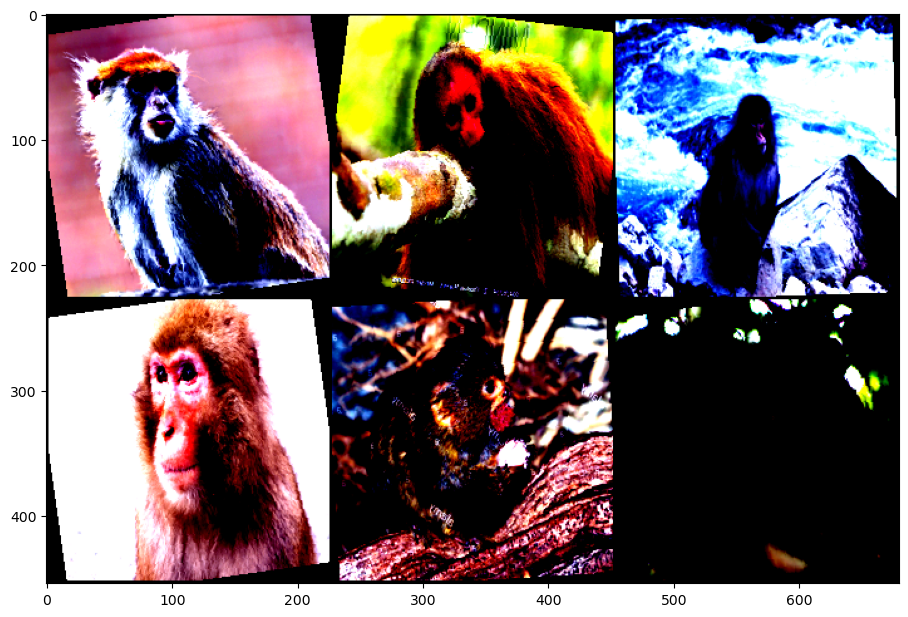

In [15]:
show_transformed_image(train_dataset)

In [16]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

## Training Methods

In [17]:
def set_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
    else:
        dev = "cpu"
    return torch.device(dev)

In [18]:
def train_nn(model, train_loader, test_loader, criterion, optimizer, n_epochs):
    device = set_device()
    
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            total += labels.size(0)
            
            optimizer.zero_grad()
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            running_corrects += (labels == predicted).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * running_corrects / total
        
        print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")
    
    test_acc = evaluate_on_test_set(model, test_loader)
    return test_acc


In [19]:
def evaluate_on_test_set(model, test_loader):
    model.eval()
    predicted_correctly_on_epoch = 0
    total = 0
    
    device = set_device()
    
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            total += labels.size(0)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            predicted_correctly_on_epoch += (predicted == labels).sum().item()
    
    epoch_acc = 100 * predicted_correctly_on_epoch / total
    return epoch_acc


In [20]:
def run_model(model_name, model):
    device = set_device()
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    acc = train_nn(model, train_loader, test_loader, criterion, optimizer, n_epochs=10)
    
    results.append((model_name, acc))

In [21]:
results = []


# ResNet18
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
run_model("ResNet18", model)


# VGG16
model = models.vgg16(pretrained=True)
model.classifier[6] = nn.Linear(4096, 10)
run_model("VGG16", model)


# MobileNetV2
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
run_model("MobileNetV2", model)


# EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
run_model("EfficientNet-B0", model)


# DenseNet121
model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 10)
run_model("DenseNet121", model)


c:\Users\Shafqat1205\anaconda3\envs\amar_jayga\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Shafqat1205\anaconda3\envs\amar_jayga\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Loss=0.7247, Acc=76.48%
Epoch 2: Loss=0.1006, Acc=96.72%
Epoch 3: Loss=0.0665, Acc=97.81%
Epoch 4: Loss=0.0687, Acc=97.81%
Epoch 5: Loss=0.0503, Acc=98.27%
Epoch 6: Loss=0.1311, Acc=96.81%
Epoch 7: Loss=0.0416, Acc=98.45%
Epoch 8: Loss=0.0191, Acc=99.64%
Epoch 9: Loss=0.0079, Acc=99.82%
Epoch 10: Loss=0.0039, Acc=100.00%


c:\Users\Shafqat1205\anaconda3\envs\amar_jayga\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Shafqat1205/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:48<00:00, 11.4MB/s] 


...

Epoch 1: Loss=1.2236, Acc=71.19%
Epoch 2: Loss=0.1574, Acc=95.90%
Epoch 3: Loss=0.0463, Acc=99.36%
Epoch 4: Loss=0.0369, Acc=99.45%
Epoch 5: Loss=0.0240, Acc=99.73%
Epoch 6: Loss=0.0190, Acc=99.64%
Epoch 7: Loss=0.0142, Acc=99.82%
Epoch 8: Loss=0.0131, Acc=99.64%
Epoch 9: Loss=0.0205, Acc=99.73%
Epoch 10: Loss=0.0205, Acc=99.73%


c:\Users\Shafqat1205\anaconda3\envs\amar_jayga\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Shafqat1205/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:02<00:00, 11.5MB/s]


Epoch 1: Loss=0.5782, Acc=83.32%
Epoch 2: Loss=0.0864, Acc=97.81%
Epoch 3: Loss=0.1117, Acc=96.72%
Epoch 4: Loss=0.0673, Acc=98.27%
Epoch 5: Loss=0.0381, Acc=99.36%
Epoch 6: Loss=0.0243, Acc=99.09%
Epoch 7: Loss=0.0317, Acc=99.27%
Epoch 8: Loss=0.0480, Acc=98.63%
Epoch 9: Loss=0.0536, Acc=98.18%
Epoch 10: Loss=0.0849, Acc=97.45%


In [22]:
print("\nModel Performance:\n")
print("{:<20} {:<15}".format("Model", "Test Accuracy (%)"))
print("-" * 35)

for name, acc in results:
    print("{:<20} {:<15.2f}".format(name, acc))



Model Performance:

Model                Test Accuracy (%)
-----------------------------------
ResNet18             98.90          
VGG16                9.56           
MobileNetV2          98.53          
EfficientNet-B0      98.16          
DenseNet121          95.59          
